Can money buy a top place in English football? A study of Top 4 finishes and wages in the English Premier League. 

## Introduction

The English Premier League (EPL) is the top level of professional football in England, and one of the most popular and highest earning sports leagues in the world. Unfortunately for some teams, the lack of a salary cap allows higher earning clubs to spend large amounts of money to buy and pay top players huge wages.  Between seasons, teams spend several billion Great British Pounds (GPB) in total, buying new players to improve their squads and fight for higher and higher places in the league standings, hoping to make it to #1. 

The question in this study is: is the spending on wages of the English Premier League clubs that finish in the top four places each season higher than that of the other sixteen clubs? To answer this I will be using fifteen seasons worth of data on final league standings from 2010 to 2015 that are publicly available from the EPL, combined with estimated wages from the most trusted source on the internet (2025-2026 Premier League Salaries). This data is appropriate because it has all of the information needed to create the two sample groups, and then compare the wages of those two groups. 

The main columns I will be using are:

place - In what position did the team finish that season, 1-20. This will be used to create a 'place category' column, to identify and segregate the teams that finished in the top four positions each season. This will be our sample of 'winning' teams. Top four teams will be enoded with a 1, other teams encoded with a 0.  

wages - The total base compensation paid to players for the season in Great British Pounds (GPB), which will be used for the hypothesis testing. This will also be used to create a 'wage rank' column, which will number all teams by the size of their wage bill each season. This will allow the teams to be compared by the relative size of their wage bill, to normalize the data over the course of the 15 seasons and give a different comparison. 

## Data Analysis and Statistical Inference

To answer the research question, this study will be using a one-tailed independent two-sample T-test. This is the correct test because it will allow the means of the two groups (top and other) to be compared. A Z-test is not used in this case because the population variance is unknown, and is instead being estimated from the sample. If the two groups do spend a different amount of money on wages, I will find the difference in the means to determine by how much. My overall approach in this study is to visualize the data, perform the T-test, and then use the resulting statistics to form a conclusion and answer the research question. 

H0: Fail to reject the null: The top teams do not spend significant more money on wages than the other teams. 

HA: Reject the Null: The top teams do spend significantly more money on wages than the other teams. 

The results of the test are to reject the null, and conclude that top teams do spend significantly more money on wages than other teams. The p-value in this case is quite small, 9384 x 10^-22. This tells us that there is only a miniscule chance that we would get these results if wages did not, in fact, have any effect on team success. The T-statistic in this case is over 13, which is a highly significant result, meaning the null hypothesis can be rejected with a high level of confidence. 

## Conclusion and Future Direction

The key finding from this study are that there is a significant difference in how much the top teams spend, by nearly 83 million GPB per season. This is a very significant amount, since the average salary per season the last fifteen years is about 80 million. The analysis also finds that wages has a very large effect size of approximately 2.138, meaning that spending more money is very effective at improving a team's performance. It is also interesting to note that the data is fairly widely distributed, meaning many teams have overperformed and underperformed the mean over the last fifteen seasons. So while wages are a top indicator of a high place in the EPL, it isn't a guarantee. Teams have shown an ability to punch much higher than their wages would suggest, while others have performed poorly despite high wage bills. An interesting point is that on the scatterplot you can see on lone dot right at the top, which was Leicster City F.C. in the 2015-2016 season coming in first place, despite having the 12th highest wage bill that season. Conversely you can see a dot down in the bottom right, where Manchester United finished fifteenth in a recent season, despite having the fourth highest wages. 

For future research it would be useful to study the teams that have greatly outperformed their wages to see if any commonalities can be found. It would be interesting to see if the players on those teams were sold off for large amounts and received much larger saleries, bringing the wage to performance ratio back in line over time. Could there be influences from effective recruiting departments or groups of successful youth players that allowed the overperforming clubs to pay less for better players for a time? It could also be the effect of coaching, or underperforming top teams, or even an element of random chance to their success. 


## Works Cited

2025-2026 Premier League Salaries and Contracts." Capology: Football Salaries & Finances, www.capology.com/uk/premier-league/salaries/. Accessed 10 Apr. 2026.

Sharma, Devanshu. "A Comprehensive Review of Factors Affecting Team Rankings in the English Premier League." International Journal of Research and Analytical Reviews (IJRAR), vol. 11, no. 4, Apr. 2024, pp. 248–254, www.ijrar.org/papers/IJRAR24D1157.pdf.


Step 1: Import python packages and data. 

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.power import NormalIndPower, TTestIndPower, TTestPower

In [98]:
#Load data from excel sheet 
df = pd.read_excel('EPL Table.xlsx')

#create column ranking teams each season by wages. 
df['wage rank'] = df.groupby('season')['wages'].rank(method='min', ascending=False)

#Create a column called 'place category' to separate data into two groups, Top 4 finishers and all other teams. 
df['place category'] = pd.cut(df['place'], bins = [0,4,20], labels=[1, 0])


#df.head(40)
#df.info()
#df.describe()

,place,team,goals for,goals against,goal difference,points,season,wages,wage rank,place category
0,1,Liverpool,86,41,45,84,2024,178380800,3.0,1
1,2,Arsenal,69,34,35,74,2024,189332000,2.0,1
2,3,Manchester City,72,44,28,71,2024,223875600,1.0,1
3,4,Chelsea,64,43,21,69,2024,156338000,5.0,1
4,5,Newcastle United,68,47,21,66,2024,116584000,8.0,0
5,6,Aston Villa,58,51,7,66,2024,129537200,7.0,0
6,7,Nottingham Forest,58,46,12,65,2024,92677000,9.0,0
7,8,Brighton & Hove Albion,66,59,7,61,2024,64500000,16.0,0
8,9,Bournemouth,58,46,12,56,2024,64800000,15.0,0
9,10,Brentford,66,57,9,56,2024,54600000,18.0,0


Step 2: Explore Raw Data

C:\Users\obruc\AppData\Local\Temp\ipykernel_23204\2843474832.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Top Teams','Other Teams'])


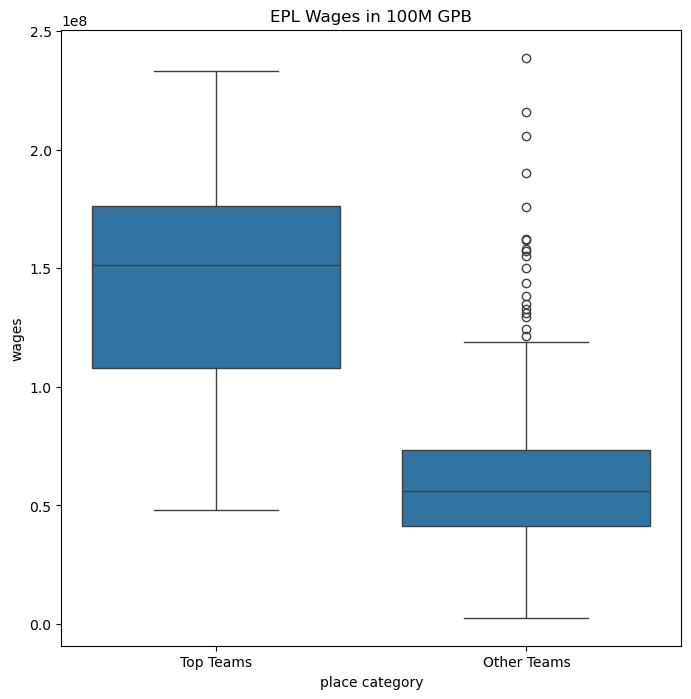

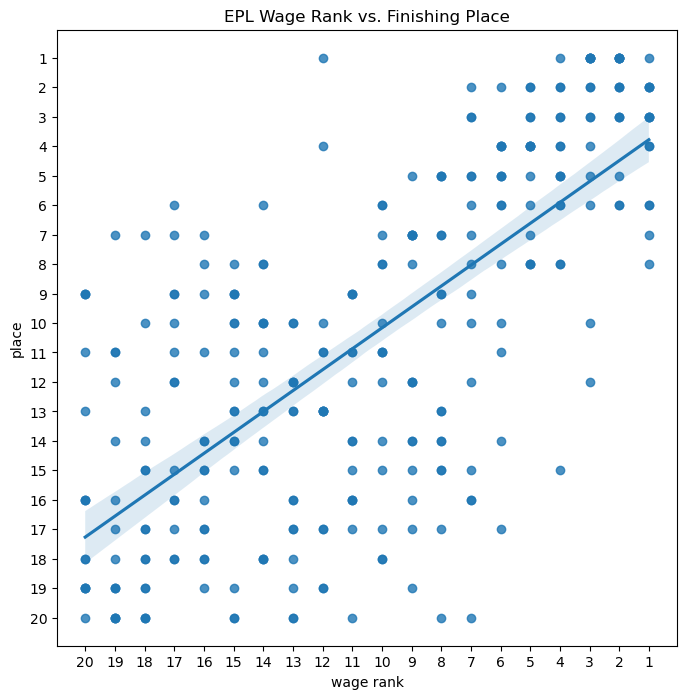

In [116]:
plt.figure(figsize=(8, 8))
ax = sns.boxplot(x="place category", y="wages", data=df)
ax.set_xticklabels(['Top Teams','Other Teams'])
plt.title("EPL Wages in 100M GPB")
plt.show()

plt.figure(figsize=(8, 8))
sns.regplot(data=df, x="wage rank", y="place")
plt.gca().invert_yaxis()
plt.gca().invert_xaxis()
plt.xticks(np.arange(1,21))
plt.yticks(np.arange(1,21))
plt.title("EPL Wage Rank vs. Finishing Place")
plt.show()

Step 3: Perform Two-Sample T-Test

In [82]:
#H0 Top teams spend the same on wages as other teams. 
#HA Top teams spend more on wages than other teams. 

top = df[df['place category'] == 1]['wages']
others = df[df['place category'] == 0]['wages']

t_stat, p_val = stats.ttest_ind(top, others, alternative='greater', equal_var=False)
print(f"t-statistic: {t_stat:.3f}, p-value: {p_val:.25f}")

if p_val < 0.05:
    print("Reject H0: Top teams spend significantly more on wages.")
else:
    print("Fail to reject H0: Top teams don't spend significantly more on wages.")

t-statistic: 13.053, p-value: 0.0000000000000000000009384
Reject H0: Top teams spend significantly more on wages.


Step 4: Interpret the Results

Step 4.1: Difference of Means

In [86]:
difference = top.mean() - others.mean()
print(f"At the mean, top teams spend {difference:.2f} more than other teams.")

At the mean, top teams spend 82654088.59 more than other teams.


Step 4.2: Effect Size

In [112]:
import pingouin as pg

effect = pg.compute_effsize(top,others, eftype='cohen')
print(f"The effect size is: {effect:.4f}")

The effect size is: 2.1376


Step 5: Display Results

In [130]:
test = pd.DataFrame({"T-Statistic": [13.053], "P-Value": ["0.0000000000000000000009384"], "Difference of Means": ["82654088.59"], "Effect Size": ["2.1376"]})
print(test.to_markdown(index=False))


|   T-Statistic |   P-Value |   Difference of Means |   Effect Size |
|--------------:|----------:|----------------------:|--------------:|
|        13.053 | 9.384e-22 |           8.26541e+07 |        2.1376 |
